In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("WineQual/WineQT.csv")

In [3]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [6]:
print(df["quality"].min() , df["quality"].max())
#Min 3 point , max 8 point

3 8


In [7]:
#print(df["quality"].mean() , df["quality"].sum())
#df["quality"].sum() / df["quality"].mean()  #total quality count
df["quality"].count()

np.int64(1143)

/tmp/ipykernel_11712/2323854219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality' , data=df , palette='viridis')


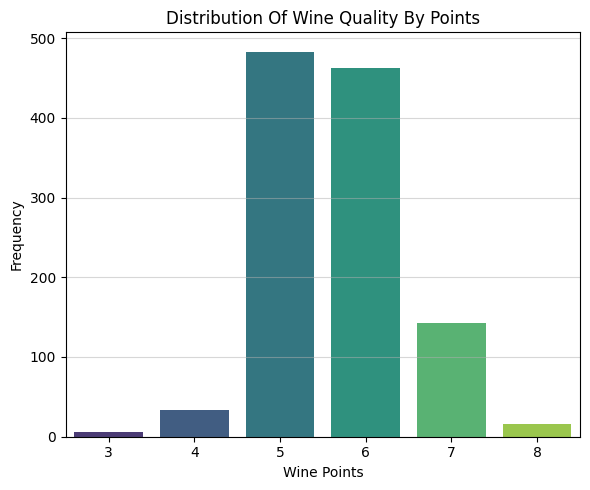

In [8]:
plt.figure(figsize=(6,5))
sns.countplot(x='quality' , data=df , palette='viridis')
plt.title("Distribution Of Wine Quality By Points")
plt.xlabel("Wine Points")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
df[(df["quality"]>4) & (df["quality"]<7)].count() #945
percentage = 945/1143*100
percentage #82.68
#82.68% of wines has valued as 5/6 stars

82.67716535433071

In [10]:
df["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

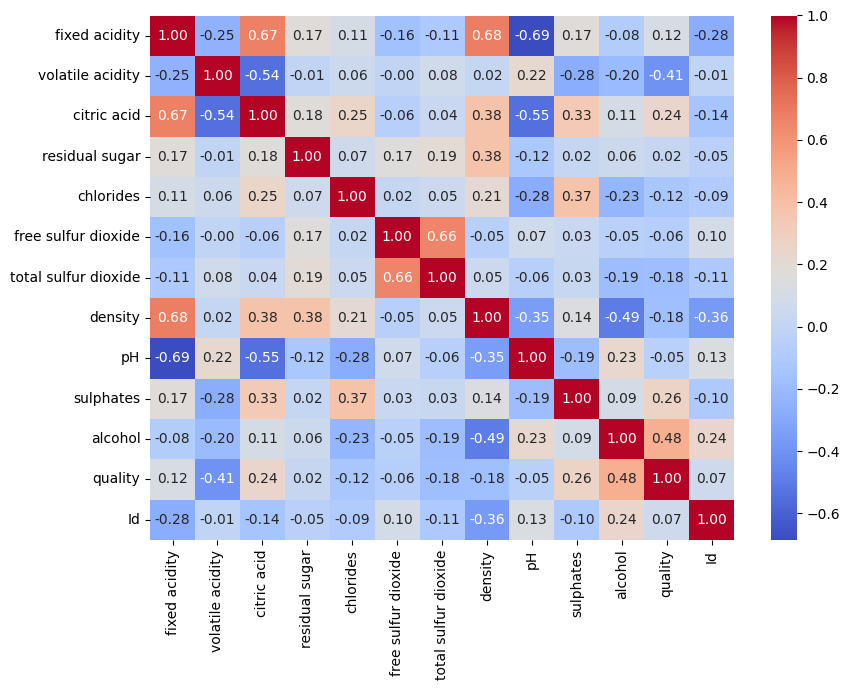

In [11]:
plt.figure(figsize=(9, 7))
cor = df.corr(numeric_only=True)
sns.heatmap(data=cor , annot=True , fmt=".2f" ,cmap = "coolwarm" ,linecolor='black' )
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

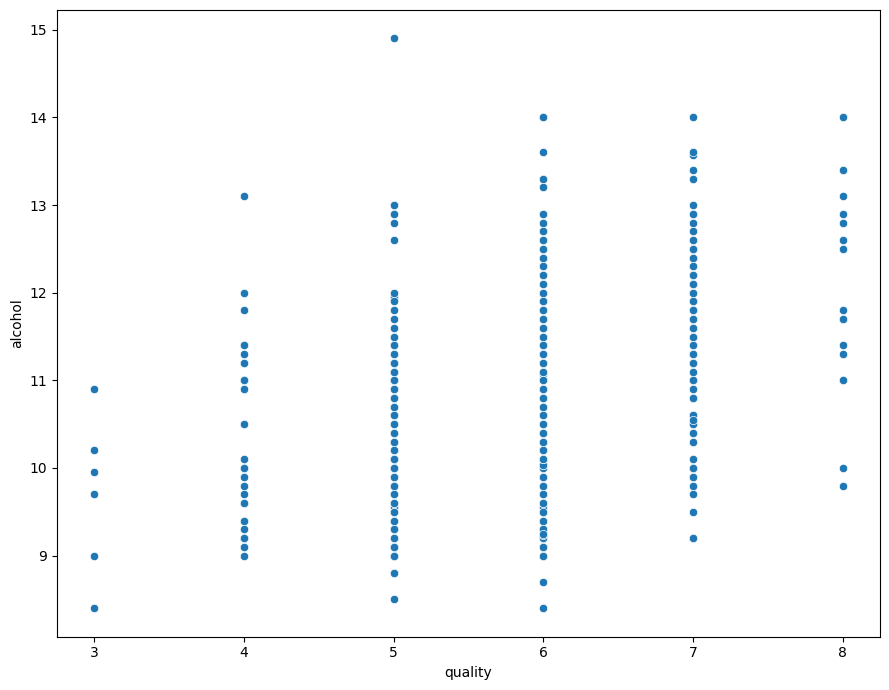

In [28]:
plt.figure(figsize=(9,7))
sns.scatterplot(x="quality",y="alcohol",data=df)
plt.tight_layout()
plt.show

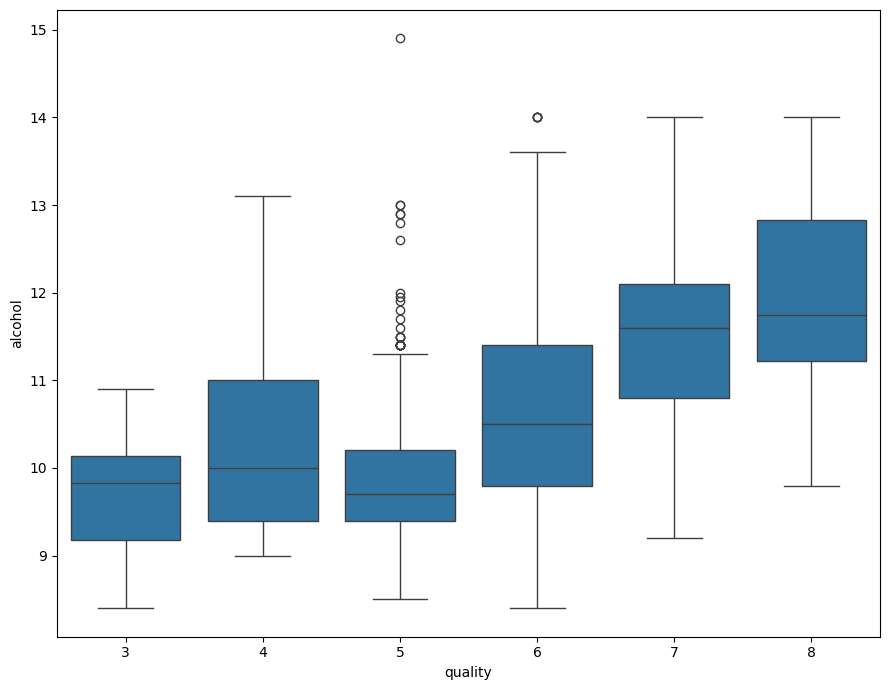

In [13]:
# Lets examine alchol and volatile acidity rates
plt.figure(figsize=(9,7))
sns.boxplot(x="quality" , y="alcohol",data=df)
plt.tight_layout()
plt.show()

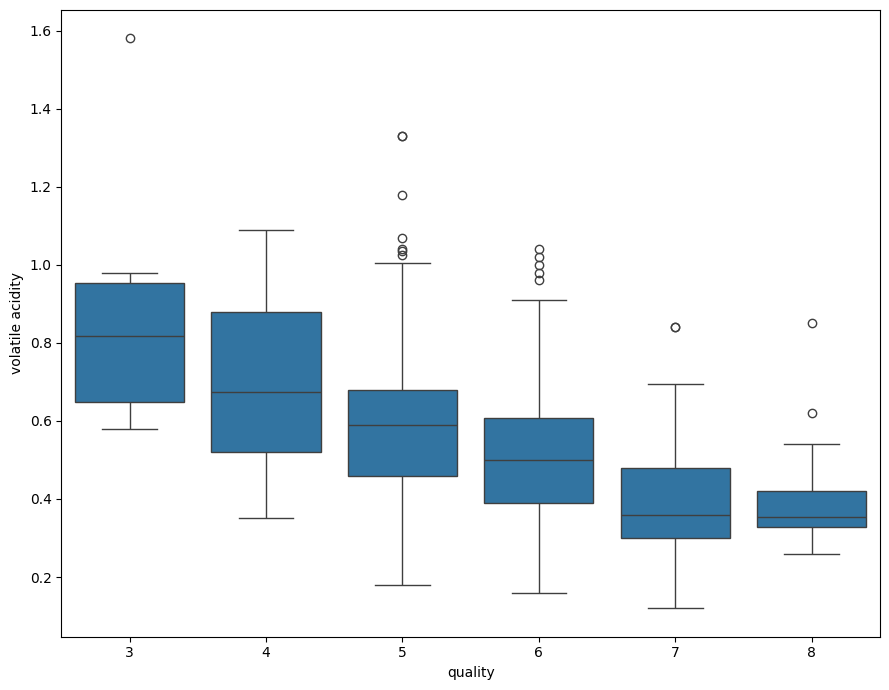

In [15]:
plt.figure(figsize=(9,7))
sns.boxplot(x="quality",y="volatile acidity",data=df)
plt.tight_layout()
plt.show()

In [16]:
def categorize_quality(quality):
    if quality <= 4:
        return "bad"
    elif quality <=6:
        return "mid"
    else:
        return "good"

In [22]:
df["categorize_quality"]=df["quality"].apply(categorize_quality)
df["categorize_quality"].head(3)

0    mid
1    mid
2    mid
Name: categorize_quality, dtype: object

In [23]:
df["categorize_quality"].value_counts()

categorize_quality
mid     945
good    159
bad      39
Name: count, dtype: int64